In [ ]:
from datasets import load_dataset

ds = load_dataset("lmms-lab/COCO-Caption2017", split="val")
len(ds)
ds[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/val-00000-of-00002.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

data/val-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

data/test-00000-of-00014.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

...

data/test-00012-of-00014.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

data/test-00013-of-00014.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

Generating val split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40670 [00:00<?, ? examples/s]

{'question_id': '000000179765.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>,
 'question': 'Please carefully observe the image and come up with a caption for the image.',
 'answer': ['A black Honda motorcycle parked in front of a garage.',
  'A Honda motorcycle parked in a grass driveway',
  'A black Honda motorcycle with a dark burgundy seat.',
  'Ma motorcycle parked on the gravel in front of a garage',
  'A motorcycle with its brake extended standing outside'],
 'id': 38,
 'license': 3,
 'file_name': '000000179765.jpg',
 'coco_url': 'http://images.cocodataset.org/val2017/000000179765.jpg',
 'height': 480,
 'width': 640,
 'date_captured': '2013-11-15 14:02:51'}

A black Honda motorcycle parked in front of a garage.


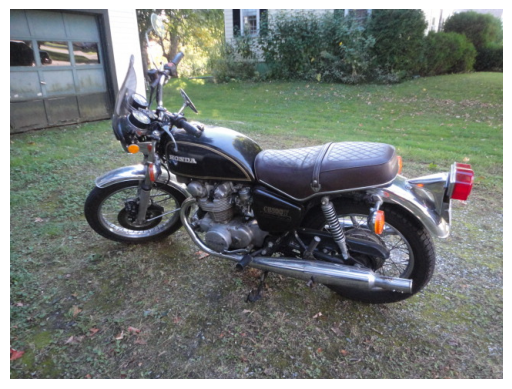

In [ ]:
from matplotlib import pyplot as plt

plt.imshow(ds[0]["image"])
plt.axis("off")
print(ds[0]["answer"][0])

In [ ]:
import pandas as pd

rows = []
# Explicitly get the first 20 examples as a list of dictionaries
examples_list = ds.select(range(20)).to_list()

for ex in examples_list:
    rows.append({
        "image_id": ex["question_id"],
        "caption": ex["answer"][0],
        "width": ex["width"],
        "height": ex["height"]
    })

df_preview = pd.DataFrame(rows)
df_preview

,image_id,caption,width,height
0,000000179765.jpg,A black Honda motorcycle parked in front of a ...,640,480
1,000000190236.jpg,An office cubicle with four different types of...,640,393
2,000000331352.jpg,A small closed toilet in a cramped space.,351,500
3,000000517069.jpg,Two women waiting at a bench next to a street.,640,480
4,000000182417.jpg,A beautiful dessert waiting to be shared by tw...,640,480
5,000000046378.jpg,A cat eating a bird it has caught.,640,360
6,000000093437.jpg,A shot of an elderly man inside a kitchen.,640,361
7,000000172330.jpg,A cat in between two cars in a parking lot.,640,480
8,000000472678.jpg,An office cubicle with multiple computers in it,640,480
9,000000314251.jpg,A parade of motorcycles is going through a gro...,640,480


In [ ]:
rows = []

for ex in ds:
    rows.append({
        "image_id": ex["question_id"],
        "caption": ex["answer"][0],
        "width": ex["width"],
        "height": ex["height"],
        "file_name": ex["file_name"],
        "coco_url": ex["coco_url"]
    })

df_full = pd.DataFrame(rows)
df_full.head()

,image_id,caption,width,height,file_name,coco_url
0,000000179765.jpg,A black Honda motorcycle parked in front of a ...,640,480,000000179765.jpg,http://images.cocodataset.org/val2017/00000017...
1,000000190236.jpg,An office cubicle with four different types of...,640,393,000000190236.jpg,http://images.cocodataset.org/val2017/00000019...
2,000000331352.jpg,A small closed toilet in a cramped space.,351,500,000000331352.jpg,http://images.cocodataset.org/val2017/00000033...
3,000000517069.jpg,Two women waiting at a bench next to a street.,640,480,000000517069.jpg,http://images.cocodataset.org/val2017/00000051...
4,000000182417.jpg,A beautiful dessert waiting to be shared by tw...,640,480,000000182417.jpg,http://images.cocodataset.org/val2017/00000018...


In [ ]:
df_full.to_excel("COCO_full_view.xlsx", index=False)

In [ ]:
subset = ds.shuffle(seed=42).select(range(200))
subset

Dataset({
    features: ['question_id', 'image', 'question', 'answer', 'id', 'license', 'file_name', 'coco_url', 'height', 'width', 'date_captured'],
    num_rows: 200
})

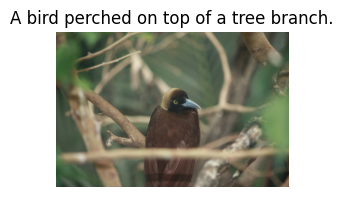

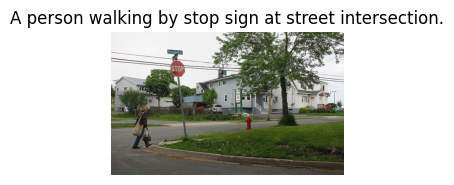

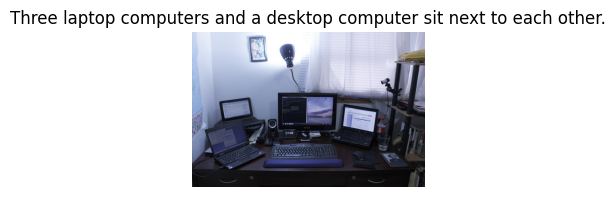

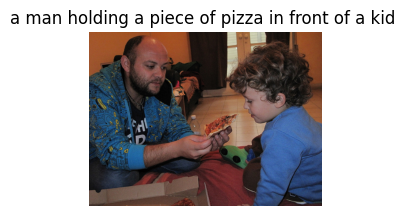

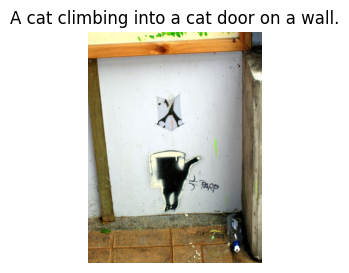

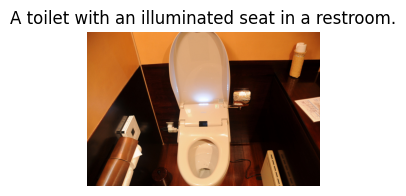

In [ ]:
import matplotlib.pyplot as plt

for i in range(6):
    plt.figure(figsize=(3,3))
    plt.imshow(subset[i]["image"])
    plt.title(subset[i]["answer"][0])
    plt.axis("off")

In [ ]:
subset.save_to_disk("/content/coco_subset_200")

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_from_disk
subset = load_from_disk("/content/coco_subset_200")
len(subset)

200

In [ ]:
import pandas as pd
import numpy as np

rows = []

for ex in subset:

    # safe image handling
    img = ex["image"]
    img = img.convert("RGB")
    arr = np.array(img)

    # safe caption
    cap = ex.get("clean_caption", ex["answer"][0])

    # safe metadata
    width = ex.get("width", arr.shape[1])
    height = ex.get("height", arr.shape[0])

    # compute brightness + aspect ratio safely
    brightness = float(arr.mean())
    aspect = width / height

    rows.append({
        "image_id": ex.get("question_id", None),
        "file_name": ex.get("file_name", None),
        "caption": cap,
        "width": width,
        "height": height,
        "aspect_ratio": round(aspect, 4),
        "brightness": round(brightness, 2)
    })

df200 = pd.DataFrame(rows)
df200.head()

,image_id,file_name,caption,width,height,aspect_ratio,brightness
0,000000561009.jpg,000000561009.jpg,A bird perched on top of a tree branch.,640,427,1.4988,99.35
1,000000343496.jpg,000000343496.jpg,A person walking by stop sign at street inters...,640,393,1.6285,114.29
2,000000097994.jpg,000000097994.jpg,Three laptop computers and a desktop computer ...,640,427,1.4988,115.30
3,000000018150.jpg,000000018150.jpg,a man holding a piece of pizza in front of a kid,640,480,1.3333,70.14
4,000000456292.jpg,000000456292.jpg,A cat climbing into a cat door on a wall.,480,640,0.7500,157.23


In [ ]:
subset[0].keys()

dict_keys(['question_id', 'image', 'question', 'answer', 'id', 'license', 'file_name', 'coco_url', 'height', 'width', 'date_captured'])

In [ ]:
df200.to_excel("COCO_subset_200.xlsx", index=False)

In [ ]:
!zip -r coco_subset_200.zip coco_subset_200

  adding: coco_subset_200/ (stored 0%)
  adding: coco_subset_200/dataset_info.json (deflated 84%)
  adding: coco_subset_200/.ipynb_checkpoints/ (stored 0%)
  adding: coco_subset_200/state.json (deflated 37%)
  adding: coco_subset_200/data-00000-of-00001.arrow (deflated 1%)
